# 04. Production Simulation

### AAI-590 Group 9: Tyler Clinscales, Edwin Merchan, Geoffrey Fadera
---

    This notebook contains three major sections:
        1. Production Pipeline Execution 
        2. Evaluation/Analysis of Results
        3. Future Work


---
### Section 1. Production Pipeline Execution
    For each time interval:
        1. Batch of "New Images" (already preprocessed)
        2. Batch Inference using previous most recently fine-tuned version of the deployed model (on both in-location and out-location datasets)
        3. Calibrate using most recently updated calibration data
        4. Active Learning - Auto Labelling of Uncertain Images requiring annotations via a Confidence Threshold    
        5. Annotation is simulated by using the ground true label from the original meta data (assuming it is correct)
        6. Fine Tune the model using ONLY the newly 'annotated' uncertain samples
        7. fine-tuning mechanics are available in wildscan_ml_system.py
        8. predict again on both in and out loc dataset
        9. evaluate, store metrics for later analysis
        10. prepare calibration data for next cycle. add newly annotated uncertain samples to previous calibration data and cap length to recent 1 year
        11. save model, calibration data, metrics, prediction files


In [1]:
# Step 1. Setup and Imports
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

import subprocess

def get_repo_root():
    return subprocess.check_output(['git', 'rev-parse', '--show-toplevel']).decode('utf-8').strip()
repo_root = get_repo_root()
print(repo_root)

src_path = os.path.join(repo_root, 'src')
# Add src_path to sys.path if not already present
if src_path not in sys.path:
    sys.path.insert(0, repo_root)
    sys.path.insert(0, src_path)
#sys.path.append(str(repo_root))

# Set random seeds for reproducibility
RANDOM_SEED = 42


import logging
# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(filename)s:%(lineno)d - %(funcName)s() - %(message)s"
)
logger = logging.getLogger(__name__)

def set_seed(seed: int):
    # Python built‐ins
    random.seed(seed)
    np.random.seed(seed)

    # PyTorch CPU & CUDA
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # PyTorch MPS (Apple GPU)
    if torch.backends.mps.is_available():
        try:
            # New in PyTorch 2+: seeds MPS generator
            torch.mps.manual_seed(seed)
        except AttributeError:
            # Fallback pre–PyTorch 2.0: no direct MPS seeding, CPU generator only
            torch.manual_seed(seed)

    # Enforce deterministic algorithms where possible
    torch.use_deterministic_algorithms(True)
    # For CUDA backends only:
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# Example usage
set_seed(RANDOM_SEED)
print(f"Project root: {repo_root}")

/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan
Project root: /Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan


In [2]:
# Step 2. Import Required Classes 

import importlib
import wildscan_ml_system
import custom_models
import trainer


importlib.reload(wildscan_ml_system)
importlib.reload(custom_models)
importlib.reload(trainer)

from custom_models import AnimalTemporalClassifier, AnimalClassifier, ScratchResNet
from wildscan_ml_system import SystemConfig, ProductionPipeline, ProductionConfig  


In [3]:
# Step 3: Create SystemConfig for Production Simulation Pipeline
def create_notebook_config():
    
    """Create configuration optimized for notebook pretraining"""
    def get_device():
        if torch.cuda.is_available():
            return "cuda"
        elif torch.backends.mps.is_available():
            return "mps"
        else:
            return "cpu"

    config = ProductionConfig(
        # Project settings
        project_name="WildScan_ML_System",
        experiment_name="Production_Simulation",

        device = get_device(),

        baseline_model_id = 2,
        
        # new data dir
        new_data_dir = "./production/new_data/",
        
        # contains most rcent model weights, last time interval's in-loc & out-loc data, and calibration data
        last_update_data_dir = "./production/last_update_data/", # previous time interval data 
        
        # Preprocessed images path 
        preprocessed_images_path= "../dataset/cct_resized/",

        # label mapping path
        label2idx_path = "./data_split/label_mapping.json",

        # Fine-tuning settings 
        fine_tune_batch_size=16, # lower since focusing on uncertain samples only
        learning_rate=1e-5,
        weight_decay=1e-4,
        patience = 0,
        epochs=10,  # Reduced for notebook

        # criterion
        criterion=nn.CrossEntropyLoss(),

        # Batch Inference Batch Size (Depends on GPU memory)
        inference_batch_size=128,  # Reduced for notebook

        # confidence threshold for uncertainty sampling and human annotation task
        confidence_threshold=0.87,  # Reduced for notebook
        
        # tmp directory for storing intermediate results (may delete later)
        # default is ./tmp but user can specify any location
        tmp_output_dir="./production/tmp/",
        historical_data_dir= "./production/historical_data",
        
        
    )
    
    return config
# reset config if it exists
if 'config' in globals():
    del config
config = create_notebook_config()

In [4]:
# Step 4 : Load Selected Pretrained Model, calibration data, previous in-loc and out-loc testsets to Production folder
import shutil
if not os.path.exists(config.last_update_data_dir):
    os.makedirs(config.last_update_data_dir)
shutil.copy(f"./pretrained_models/model_{config.baseline_model_id}/best_model.pth", config.last_update_data_dir)
shutil.copy(f"./data_split/val-meta.csv", f"{config.last_update_data_dir}/cal-meta.csv")
shutil.copy(f"./data_split/test-meta.csv", f"{config.last_update_data_dir}/in-loc-meta.csv")
shutil.copy(f"./data_split/year1/val-meta.csv", f"{config.last_update_data_dir}/out-loc-meta.csv")

# establish base line metrics also of selected model. 
# (THIS IS HARDCODED FOR NOW ASSUMING MODEL 2 DEPLOYMENT)
baseline_metrics = {
    # save time info
    'current_year_month': "2012-02",
    'last_update_year_month': "2011-02",  # last update year and month

    # save number of samples
    'num_new_samples': 0,  # number of samples in the current production dataset (in distribution)
    # number of uncertain samples detected
    'num_uncertain_samples': 0,  # number of uncertain samples detected in in-distribution production set

    # Supervised Metrics for evaluation of production simulation
    # pre fine-tuning metrics 
    'pre_finetune' : {
        'in_loc': {'accuracy': 0.9026, 'f1_weighted': 0.0, 'f1_macro':0.7847},
        'out_loc': {'accuracy': 0.7949, 'f1_weighted': 0.0, 'f1_macro':0.6225},
    },
    
    # post fine-tuning metrics on current data
    'post_finetune': {  # metrics after fine-tuning
        'in_loc': {'accuracy': 0.9026, 'f1_weighted': 0.0, 'f1_macro':0.7847},
        'out_loc': {'accuracy': 0.7949, 'f1_weighted': 0.0, 'f1_macro':0.6225},
    },

    # post fine-tuning metrics on previous data
    'post_finetune_prev_data': {  # metrics after fine-tuning on previous data
        'in_loc': {'accuracy': 0.9026, 'f1_weighted': 0.0, 'f1_macro':0.7847},
        'out_loc': {'accuracy': 0.7949, 'f1_weighted': 0.0, 'f1_macro':0.6225},
    },
    
}



In [5]:
# Step 5: Load in-loc and out-loc production meta
in_loc_prod_meta_df = pd.read_csv('./production/in-loc-meta.csv')    
in_loc_prod_meta_df['date_captured'] = pd.to_datetime(in_loc_prod_meta_df['date_captured'], errors='coerce')
out_loc_prod_meta_df = pd.read_csv('./production/out-loc-meta.csv')
out_loc_prod_meta_df['date_captured'] = pd.to_datetime(out_loc_prod_meta_df['date_captured'], errors='coerce')


2025-08-13 21:13:01,727 - INFO - wildscan_ml_system.py:579 - __init__() - ============================================================
2025-08-13 21:13:01,727 - INFO - wildscan_ml_system.py:580 - __init__() - Initializing Production Pipeline execution with the followning configurations
2025-08-13 21:13:01,727 - INFO - wildscan_ml_system.py:589 - __init__() - Device: mps
2025-08-13 21:13:01,728 - INFO - wildscan_ml_system.py:597 - __init__() - Loaded label mapping with 14 classes from ./data_split/label_mapping.json
2025-08-13 21:13:01,728 - INFO - wildscan_ml_system.py:598 - __init__() - Label2Idx Mapping: {'car': 0, 'coyote': 1, 'dog': 2, 'bobcat': 3, 'rabbit': 4, 'deer': 5, 'opossum': 6, 'raccoon': 7, 'squirrel': 8, 'cat': 9, 'bird': 10, 'skunk': 11, 'rodent': 12, 'fox': 13}
2025-08-13 21:13:01,729 - INFO - wildscan_ml_system.py:631 - __init__() - ============================================================
2025-08-13 21:13:01,729 - INFO - wildscan_ml_system.py:1245 - run_pipeline() 

Last update time: 2012-02-29 23:56:58, Next update time: 2013-02-28 23:56:58
Last update year-month: 2012-02, Next update year-month: 2013-02


2025-08-13 21:13:02,219 - INFO - wildscan_ml_system.py:756 - load_most_recent_model_state_and_data() - Loaded model weights from production/last_update_data/best_model.pth
2025-08-13 21:13:02,226 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (1463, 16)
2025-08-13 21:13:02,226 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-13 21:13:02,226 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with 1463 samples.
2025-08-13 21:13:02,227 - INFO - wildscan_ml_system.py:769 - load_most_recent_model_state_and_data() - Loaded calibration data from previous time interval ./production/last_update_data//cal-meta.csv
2025-08-13 21:13:02,252 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (7188, 16)
2025-08-13 21:13:02,252 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-13 21:13:02,253 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with

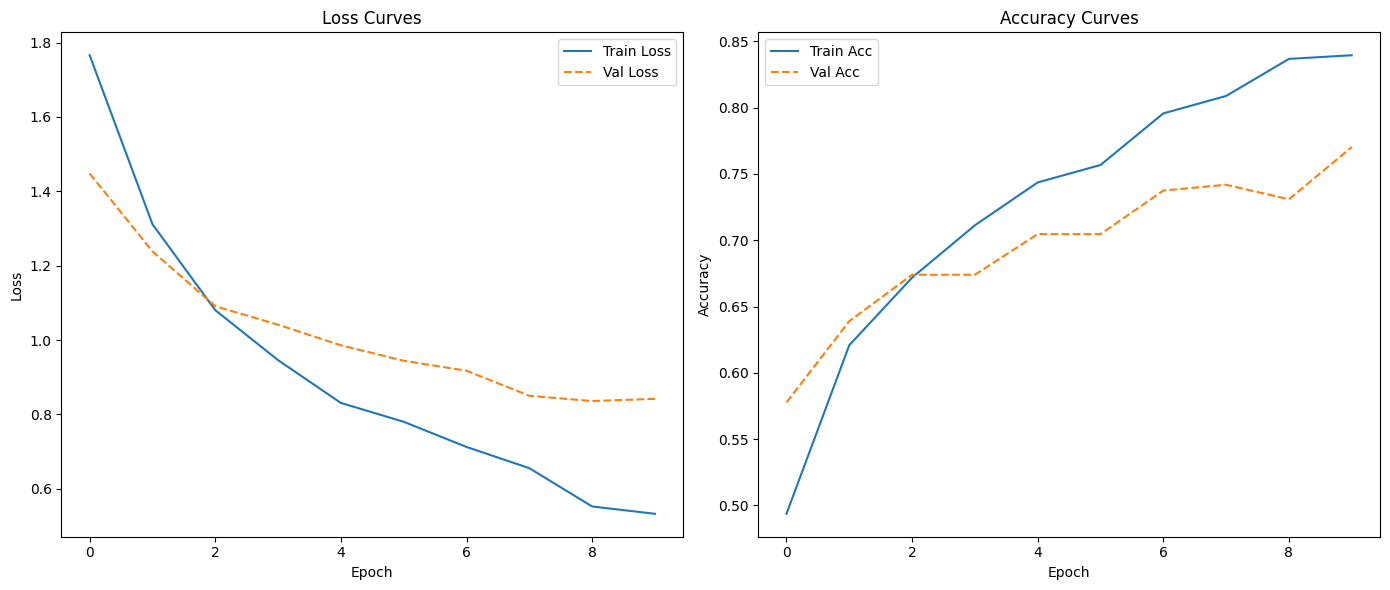

2025-08-13 21:15:07,085 - INFO - wildscan_ml_system.py:1115 - _fine_tune_model() - Deployed Model AnimalTemporalClassifier_ResNet18 loaded with best weights.
2025-08-13 21:15:07,090 - INFO - wildscan_ml_system.py:963 - run_production_simulation() - ... Prod Step 5: Re-Evaluating Fine-Tuned Model on In-Location Production Data
2025-08-13 21:15:07,090 - INFO - wildscan_ml_system.py:877 - _evaluate_model_on_dataloader() - Evaluating model on dataloader...
2025-08-13 21:15:07,092 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 21:15:31,055 - INFO - wildscan_ml_system.py:887 - _evaluate_model_on_dataloader() - Adjusting Confidence Scores via TvA to identify uncertain predictions...
2025-08-13 21:15:31,077 - INFO - wildscan_ml_system.py:895 - _evaluate_model_on_dataloader() - Found 1629 uncertain samples (18.2%)
2025-08-13 21:15:31,091 - INFO - wildscan_ml_system.py:901 - _evaluate_model_on_dataloader() - simulation debug: Accuracy: 0.9497, F1 (weighted): 

Last update time: 2013-02-28 22:01:38, Next update time: 2014-02-28 22:01:38
Last update year-month: 2013-02, Next update year-month: 2014-02


2025-08-13 21:16:33,439 - INFO - wildscan_ml_system.py:756 - load_most_recent_model_state_and_data() - Loaded model weights from production/last_update_data/best_model.pth
2025-08-13 21:16:33,446 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (1629, 20)
2025-08-13 21:16:33,446 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-13 21:16:33,447 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with 1629 samples.
2025-08-13 21:16:33,447 - INFO - wildscan_ml_system.py:769 - load_most_recent_model_state_and_data() - Loaded calibration data from previous time interval ./production/last_update_data//cal-meta.csv
2025-08-13 21:16:33,469 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (8953, 15)
2025-08-13 21:16:33,469 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-13 21:16:33,469 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with

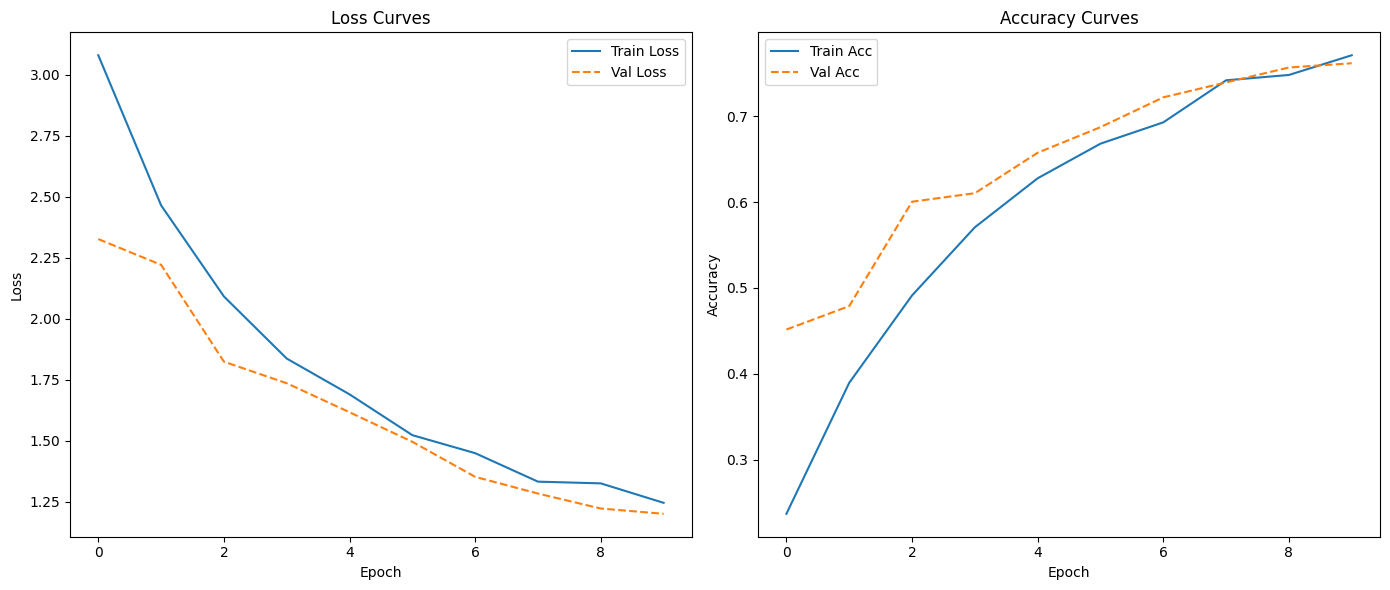

2025-08-13 21:18:12,314 - INFO - wildscan_ml_system.py:1115 - _fine_tune_model() - Deployed Model AnimalTemporalClassifier_ResNet18 loaded with best weights.
2025-08-13 21:18:12,315 - INFO - wildscan_ml_system.py:963 - run_production_simulation() - ... Prod Step 5: Re-Evaluating Fine-Tuned Model on In-Location Production Data
2025-08-13 21:18:12,316 - INFO - wildscan_ml_system.py:877 - _evaluate_model_on_dataloader() - Evaluating model on dataloader...
2025-08-13 21:18:12,321 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 21:18:22,489 - INFO - wildscan_ml_system.py:887 - _evaluate_model_on_dataloader() - Adjusting Confidence Scores via TvA to identify uncertain predictions...
2025-08-13 21:18:22,499 - INFO - wildscan_ml_system.py:895 - _evaluate_model_on_dataloader() - Found 2212 uncertain samples (56.9%)
2025-08-13 21:18:22,504 - INFO - wildscan_ml_system.py:901 - _evaluate_model_on_dataloader() - simulation debug: Accuracy: 0.8264, F1 (weighted): 

Last update time: 2014-02-28 13:28:36, Next update time: 2015-02-28 13:28:36
Last update year-month: 2014-02, Next update year-month: 2015-02


2025-08-13 21:19:08,529 - INFO - wildscan_ml_system.py:756 - load_most_recent_model_state_and_data() - Loaded model weights from production/last_update_data/best_model.pth
2025-08-13 21:19:08,538 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (2214, 20)
2025-08-13 21:19:08,538 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-13 21:19:08,539 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with 2214 samples.
2025-08-13 21:19:08,539 - INFO - wildscan_ml_system.py:769 - load_most_recent_model_state_and_data() - Loaded calibration data from previous time interval ./production/last_update_data//cal-meta.csv
2025-08-13 21:19:08,549 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (3889, 15)
2025-08-13 21:19:08,550 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-13 21:19:08,550 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with

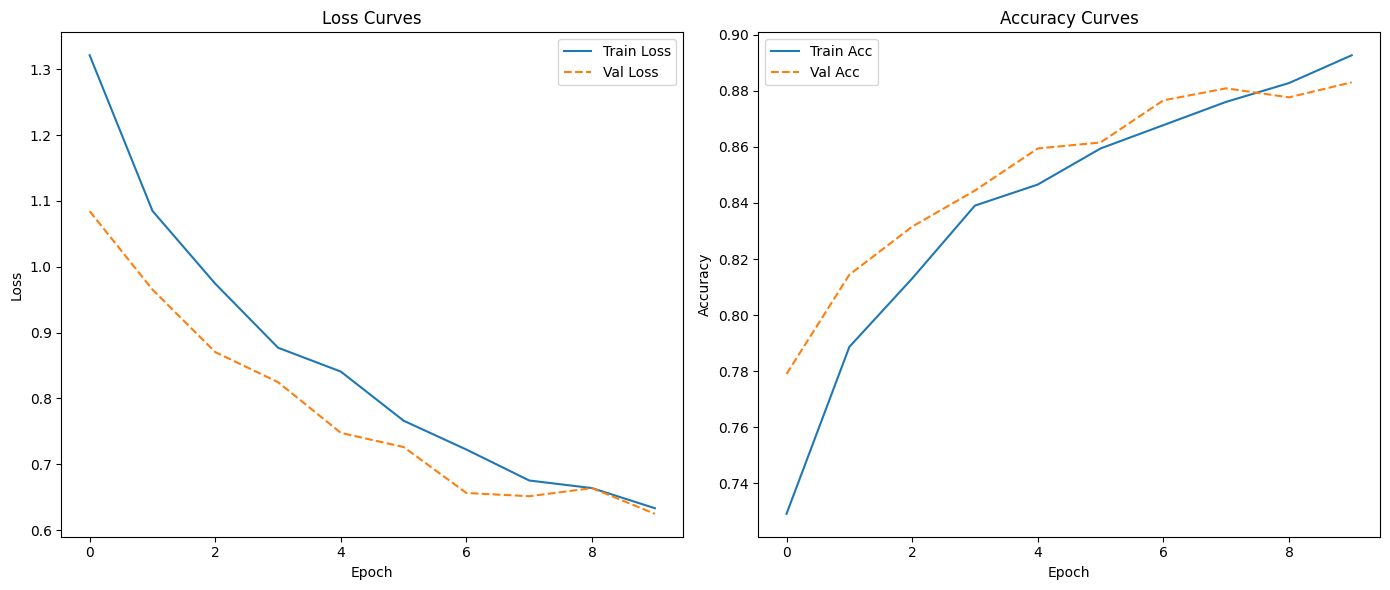

2025-08-13 21:22:29,239 - INFO - wildscan_ml_system.py:1115 - _fine_tune_model() - Deployed Model AnimalTemporalClassifier_ResNet18 loaded with best weights.
2025-08-13 21:22:29,239 - INFO - wildscan_ml_system.py:963 - run_production_simulation() - ... Prod Step 5: Re-Evaluating Fine-Tuned Model on In-Location Production Data
2025-08-13 21:22:29,239 - INFO - wildscan_ml_system.py:877 - _evaluate_model_on_dataloader() - Evaluating model on dataloader...
2025-08-13 21:22:29,241 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 21:22:42,039 - INFO - wildscan_ml_system.py:887 - _evaluate_model_on_dataloader() - Adjusting Confidence Scores via TvA to identify uncertain predictions...
2025-08-13 21:22:42,048 - INFO - wildscan_ml_system.py:895 - _evaluate_model_on_dataloader() - Found 4841 uncertain samples (93.4%)
2025-08-13 21:22:42,053 - INFO - wildscan_ml_system.py:901 - _evaluate_model_on_dataloader() - simulation debug: Accuracy: 0.9147, F1 (weighted): 

Last update time: 2015-02-20 19:32:07, Next update time: 2016-02-20 19:32:07
Last update year-month: 2015-02, Next update year-month: 2016-02
No more data to Process. Exiting...


In [6]:
# Step 6. Run Periodic Production Simulation Pipeline
# This is the main loop that runs the production simulation pipeline periodically

# set retraing interval in terms of months
retraining_interval_months = 12 # this notebook is set to 12, but we also tried 6 and 3 and the results are available in our paper
all_metrics = []
all_metrics.append(baseline_metrics)


while (True):
    last_update_meta_df = pd.read_csv(f"{config.last_update_data_dir}/in-loc-meta.csv")
    last_update_meta_df['date_captured'] = pd.to_datetime(last_update_meta_df['date_captured'], errors='coerce')
    last_update_meta_df = last_update_meta_df.sort_values(by='date_captured', ascending=True)
    last_update_time = last_update_meta_df['date_captured'].max()
    next_update_time =  last_update_time + pd.DateOffset(months=retraining_interval_months)

    last_update_ym = last_update_time.strftime('%Y-%m')
    next_update_ym = next_update_time.strftime('%Y-%m')
    print(f"Last update time: {last_update_time}, Next update time: {next_update_time}")
    print(f"Last update year-month: {last_update_ym}, Next update year-month: {next_update_ym}")


    # filter in_loc_prod_meta_df and out_loc_prod_meta_df, between last update time and next update time
    in_loc_prod_meta_df = pd.read_csv('./production/in-loc-meta.csv')    
    in_loc_prod_meta_df['date_captured'] = pd.to_datetime(in_loc_prod_meta_df['date_captured'], errors='coerce')
    in_loc_prod_meta_df = in_loc_prod_meta_df[
        (in_loc_prod_meta_df['date_captured'] > last_update_time) & 
        (in_loc_prod_meta_df['date_captured'] < next_update_time)
    ]
    out_loc_prod_meta_df = pd.read_csv('./production/out-loc-meta.csv')
    out_loc_prod_meta_df['date_captured'] = pd.to_datetime(out_loc_prod_meta_df['date_captured'], errors='coerce')
    out_loc_prod_meta_df = out_loc_prod_meta_df[
        (out_loc_prod_meta_df['date_captured'] > last_update_time) & 
        (out_loc_prod_meta_df['date_captured'] < next_update_time)
    ]

    # break the loop if no more data to process
    if(len(in_loc_prod_meta_df) < 10 and len(out_loc_prod_meta_df) < 10):
        print("No more data to Process. Exiting...")
        break

    # save csv to config.new_data_dir
    if not os.path.exists(config.new_data_dir):
        os.makedirs(config.new_data_dir)
    in_loc_prod_meta_df.to_csv(f"{config.new_data_dir}/in-loc-meta.csv", index=False)
    out_loc_prod_meta_df.to_csv(f"{config.new_data_dir}/out-loc-meta.csv", index=False)

    # ************************ #   
    production_pipeline = ProductionPipeline(config)
    current_metrics = production_pipeline.run_pipeline()
    # ************************ #

    all_metrics.append(current_metrics)

    # delete pipeline instance from gpu and cpu
    del production_pipeline

# save all_metrics to json
import json
with open(f'./production/model{config.baseline_model_id}_every{retraining_interval_months}months.json', 'w') as f:
    json.dump(all_metrics, f, indent=4)

---
### Section 2. Evaluation/Analysis of Results


2025-08-13 21:24:43,198 - INFO - category.py:223 - update() - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-13 21:24:43,201 - INFO - category.py:223 - update() - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-13 21:24:43,203 - INFO - category.py:223 - update() - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-13 21:24:43,203 - INFO - category.py:223 - update() - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before pl

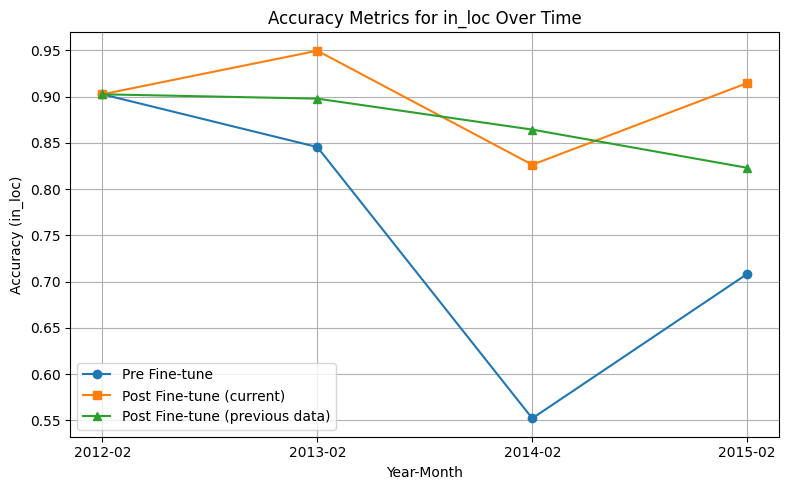

In [7]:
# Eval 1. # Plotting the metrics over time
months = [interval['current_year_month'] for interval in all_metrics]
pre = [interval['pre_finetune']['in_loc']['accuracy'] for interval in   all_metrics]
post = [interval['post_finetune']['in_loc']['accuracy'] for interval in all_metrics]
post_prev = [interval['post_finetune_prev_data']['in_loc']['accuracy'] for interval in all_metrics]
post_prev_shifted = post_prev[1:] + [np.nan]
plt.figure(figsize=(8, 5))
plt.plot(months, pre, marker='o', label='Pre Fine-tune')
plt.plot(months, post, marker='s', label='Post Fine-tune (current)')
plt.plot(months, post_prev, marker='^', label='Post Fine-tune (previous data)')
plt.xlabel('Year-Month')
plt.ylabel('Accuracy (in_loc)')
plt.title('Accuracy Metrics for in_loc Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Eval 2
# get total number of uncertain samples from all_metrics
total_uncertain_samples = sum(interval['num_uncertain_samples'] for interval in all_metrics)
print(f"Total number of uncertain samples detected: {total_uncertain_samples}")

Total number of uncertain samples detected: 8957


---
### Section 3. Future Work

    1. Fine-tuner gradual freezing of layers, optimization
    2. Should data from previous time interval be included in the fine-tuning train data?
    3. Explore time-split-cross-validation so we dont have to split the newly annotated uncertain samples into train-val. 
    4. Try other calibration methods with TvA. 
    5. Investigate the effect of n_bins when using TvA Histogram Binning,
    6. Include other Models as this is still really part of Model evaluation and Comparison